# Audification of Kepler Lightcurves
Hands on Astronomical Data Sonification, Adrián García Riber, SVO 2026

https://archive.stsci.edu/missions-and-data/kepler

This work includes data collected by the Kepler mission and obtained from the MAST data archive at the Space Telescope Science Institute (STScI). Funding for the Kepler mission is provided by the NASA Science Mission Directorate. STScI is operated by the Association of Universities for Research in Astronomy, Inc., under NASA contract NAS 5–26555.

In [1]:
from astropy.timeseries import TimeSeries
import matplotlib.pylab as plt
import numpy as np
import sounddevice as sd
import soundfile as sf

In [2]:
file = '/Users/adrian/Documents/SONIFICATION_WORKSHOP/SESSIONS/Session2/KeplerLightcurves/kplr011853905-2009166043257_llc.fits'

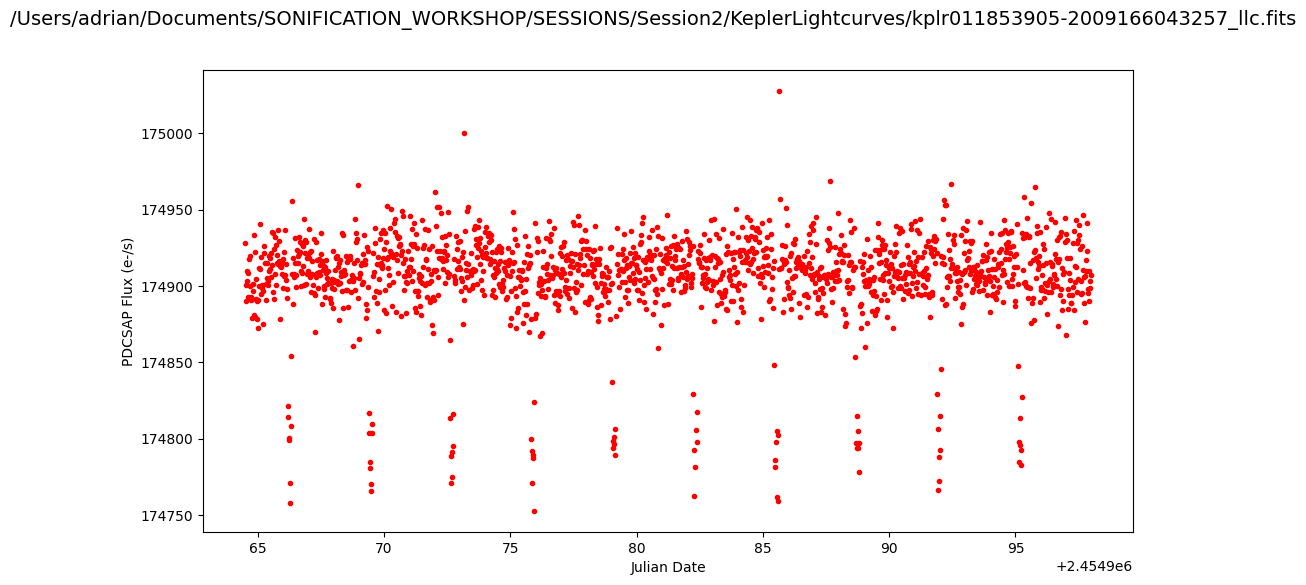

LC dimension:  1639


In [3]:
lightcurve = TimeSeries.read(file, format='kepler.fits', unit_parse_strict='silent') 

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
fig.suptitle(file, size=14)  
time = lightcurve.time.jd
flux = lightcurve['pdcsap_flux']
ax.plot(time, flux, 'r.')
ax.set_xlabel('Julian Date')
ax.set_ylabel('PDCSAP Flux (e-/s)')
plt.show()
print("LC dimension: ", len(lightcurve['pdcsap_flux']))

Kepler 4 star (KIC 11853905), RA(2000): 285.6156 DEC(2000): 50.1358, available at the Mikulsky Archive for Space Telescope (MAST).  The curve shows planetary transits with relative depth of 0.87.10−3, orbital period of 3.213 days, and duration of about 3.95 hours around the sunlike star.

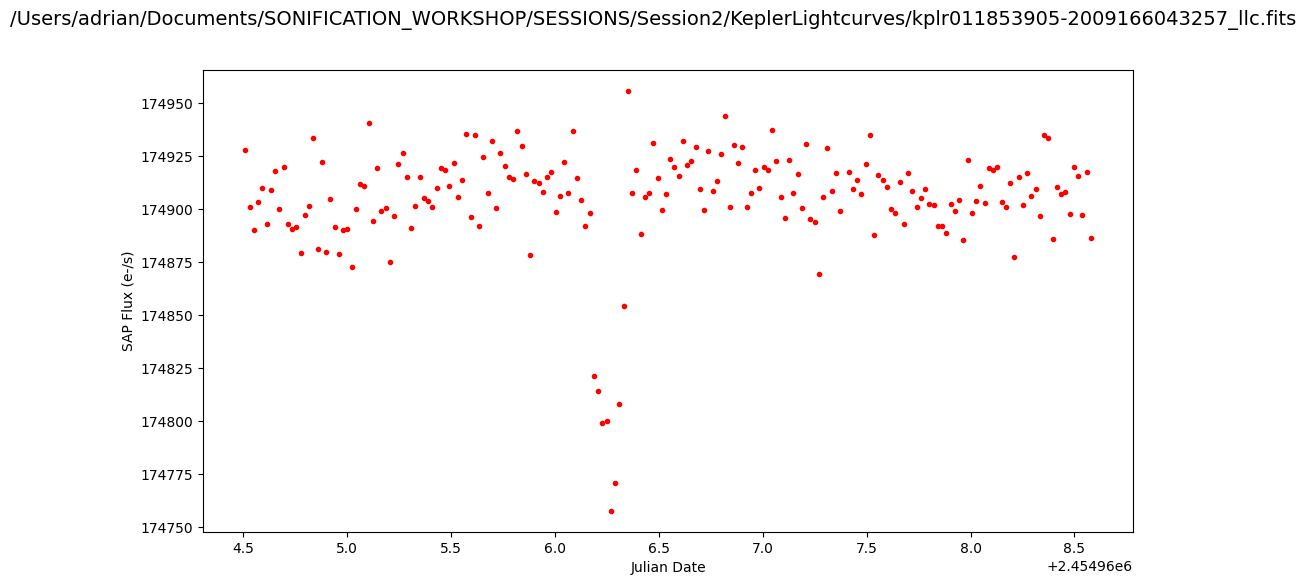

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
fig.suptitle(file, size=14)  
time = lightcurve.time.jd
flux = lightcurve['pdcsap_flux']
ax.plot(time[:200], flux[:200] , 'r.')
ax.set_xlabel('Julian Date')
ax.set_ylabel('SAP Flux (e-/s)')
plt.show()

## Search for nans

In [5]:
nan_test = np.isnan(flux)
print(nan_test)                                # [False  True ... False  True]
print(flux[nan_test])                          # [nan ... nan]
print("Number of NaNs:", len(flux[nan_test]))  # number of NaNs
print(np.where(nan_test))                      # indices of NaNs

[False False False ... False False False]
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan] electron / s
Number of NaNs: 15
(array([ 141,  287,  433,  579,  725,  802,  871,  986, 1017, 1035, 1163,
       1177, 1309, 1455, 1601]),)


In [6]:
min_flux = np.min(flux)
max_flux = np.max(flux)
print(min_flux, max_flux)

nan electron / s nan electron / s


## Cleaning 'nans'

In [7]:
mask = ~np.isnan(flux)
clean_flux = flux[mask]
clean_times = np.arange(len(clean_flux))  # Or your BJD normalized

In [8]:
len(clean_flux)

1624

In [9]:
nan_check = np.isnan(clean_flux)
print("Number of NaNs:", len(clean_flux[nan_check]))

Number of NaNs: 0


In [10]:
min_flux = np.min(clean_flux)
max_flux = np.max(clean_flux)
print(min_flux, max_flux)

174752.671875 electron / s 175027.96875 electron / s


## Exporting as wav

In [11]:
flux_norm_direct = 2 * (clean_flux - clean_flux.min()) / (clean_flux.max() - clean_flux.min()) - 1 #Normalization between -1 and 1 for wav

In [12]:
sf.write("keplerLC_0.wav", flux_norm_direct, 44100)

In [13]:
sd.play(flux_norm_direct , 44100)

Open the wav file with an audio editor (https://www.audacityteam.org/)

## Interpolation

In [14]:
import numpy as np
from scipy.signal import resample
from scipy.interpolate import interp1d

# Fourier resample (preserves power, good for periodic signals)
augmented_flux = resample(clean_flux, 44100)
augmented_times = np.arange(len(augmented_flux)) 
print(augmented_flux.shape) 

(44100,)


In [15]:
len(augmented_flux)

44100

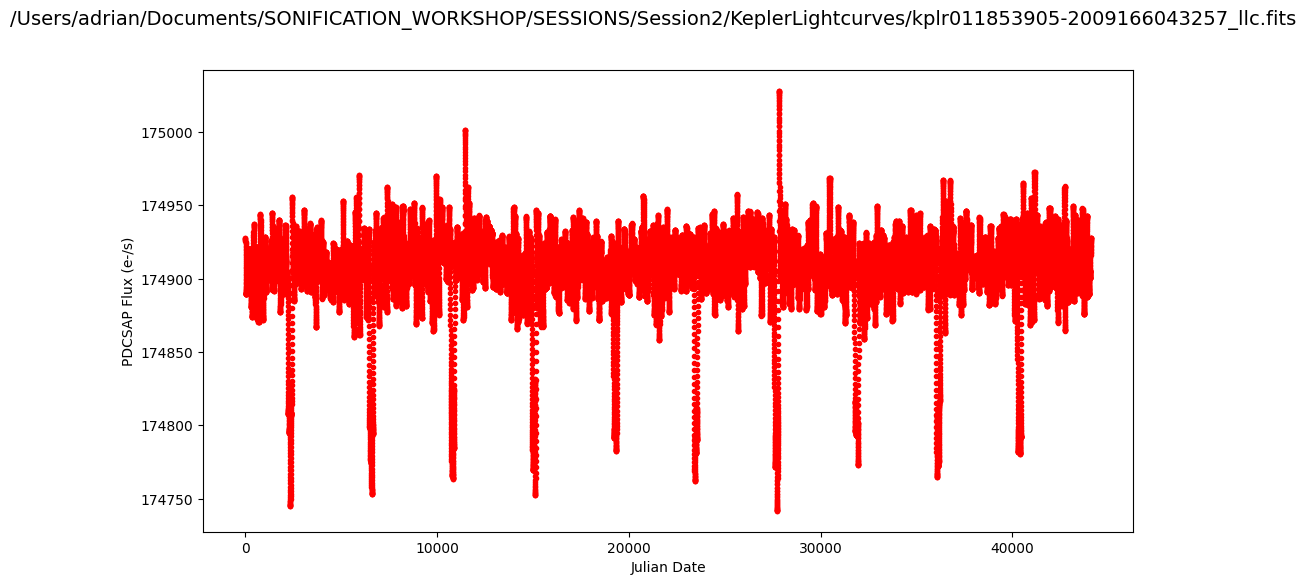

LC dimension:  1639


In [16]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
fig.suptitle(file, size=14)  
ax.plot(augmented_times, augmented_flux, 'r.')
ax.set_xlabel('Julian Date')
ax.set_ylabel('PDCSAP Flux (e-/s)')
plt.show()
print("LC dimension: ", len(lightcurve['pdcsap_flux']))

In [17]:
flux_norm_augmented = 2 * (augmented_flux - augmented_flux.min()) / (augmented_flux.max() - augmented_flux.min()) - 1

In [18]:
sf.write("keplerLC_1s.wav", flux_norm_augmented, 44100)

In [19]:
sd.play(flux_norm_augmented , 44100)

In [20]:
sd.stop()